In [ ]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvista as pv
import time
from datetime import datetime
from gravity_forward_numba import gsphere, VecWerSch_numba

In [ ]:
# Sphere parameters
xc, yc, zc = 0., 0., 2.
a = 2.0
rho = 1000.0

# Observation heights (z levels) in km
z_levels = [0.001, 0.01, 0.1, 1.0]

# Observation grid (fixed horizontal extent)
xgv = np.linspace(-10., 10., 101)
ygv = np.linspace(-10., 10., 101)
nx_obs = len(xgv)
ny_obs = len(ygv)
N_obs = nx_obs * ny_obs
print(f"\nObservation grid: {nx_obs} x {ny_obs} = {N_obs} points per z level\n")

# Refinement settings
nsub_max = 8
NSUBs = np.arange(nsub_max)

# Geographic resolution rules (used for pv.Sphere)
Lon_Res = 5 * (2 ** NSUBs)
Lat_Res = (2 ** (NSUBs + 1)) + 2

# Containers to store results for each z level
all_err_ico = []
all_err_geo = []
all_time_ico = []
all_time_geo = []

fields = ['V', 'gx', 'gy', 'gz', 'Txx', 'Txy', 'Txz', 'Tyy', 'Tyz', 'Tzz']

# Loop over each observation height (z level)
for z0 in z_levels:
    print(f"\n=== Processing z level: {z0} km ===")
    
    # Build observation grid at height z0
    X2d, Y2d = np.meshgrid(xgv, ygv)
    Z2d = z0 * np.ones_like(X2d)
    P = np.column_stack((X2d.ravel(), Y2d.ravel(), Z2d.ravel()))

    # Analytical solution
    V_ref, gx_ref, gy_ref, gz_ref, Txx_ref, Txy_ref, Txz_ref, Tyy_ref, Tyz_ref, Tzz_ref = \
        gsphere(P[:,0], P[:,1], P[:,2], xc, yc, zc, a, rho)
    ref_arrays = [V_ref, gx_ref, gy_ref, gz_ref, Txx_ref, Txy_ref, Txz_ref, Tyy_ref, Tyz_ref, Tzz_ref]

    # Initialize error and timing lists for this z level
    err_ico = {f: [] for f in fields}
    err_geo = {f: [] for f in fields}
    time_ico = []
    time_geo = []

    for idx, nsub in enumerate(NSUBs):
        print(f"  Processing nsub = {nsub}... [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")

        # --- Icosphere ---
        mesh_ico = pv.Icosphere(radius=a, center=(xc, yc, zc), nsub=nsub)
        verts_ico = mesh_ico.points  # shape (N, 3)
        faces_ico = mesh_ico.regular_faces

        t0 = time.time()
        V_i, gx_i, gy_i, gz_i, Txx_i, Txy_i, Txz_i, Tyy_i, Tyz_i, Tzz_i = \
            VecWerSch_numba(P, verts_ico, faces_ico, rho)
        t_ico = time.time() - t0
        time_ico.append(t_ico)

        cal_ico = [V_i, gx_i, gy_i, gz_i, Txx_i, Txy_i, Txz_i, Tyy_i, Tyz_i, Tzz_i]
        for field, ref, cal in zip(fields, ref_arrays, cal_ico):
            rms_ref = np.linalg.norm(ref) / np.sqrt(ref.size)
            rms_dif = np.linalg.norm(cal - ref) / np.sqrt(cal.size)
            if rms_ref < 1e-8:
                err = rms_dif
            else:
                err = rms_dif / rms_ref
            err_ico[field].append(err)

        # --- Geographic Grid ---
        theta_res = Lon_Res[idx]
        phi_res   = Lat_Res[idx]
        mesh_geo = pv.Sphere(
            radius=a,
            center=(xc, yc, zc),
            theta_resolution=theta_res,
            phi_resolution=phi_res
        )
        verts_geo = mesh_geo.points
        faces_geo = mesh_geo.regular_faces

        t0 = time.time()
        V_g, gx_g, gy_g, gz_g, Txx_g, Txy_g, Txz_g, Tyy_g, Tyz_g, Tzz_g = \
            VecWerSch_numba(P, verts_geo, faces_geo, rho)
        t_geo = time.time() - t0
        time_geo.append(t_geo)

        cal_geo = [V_g, gx_g, gy_g, gz_g, Txx_g, Txy_g, Txz_g, Tyy_g, Tyz_g, Tzz_g]
        for field, ref, cal in zip(fields, ref_arrays, cal_geo):
            rms_ref = np.linalg.norm(ref) / np.sqrt(ref.size)
            rms_dif = np.linalg.norm(cal - ref) / np.sqrt(cal.size)
            if rms_ref < 1e-8:
                err = rms_dif
            else:
                err = rms_dif / rms_ref
            err_geo[field].append(err)

    # Store results for this z level
    all_err_ico.append(err_ico)
    all_err_geo.append(err_geo)
    all_time_ico.append(time_ico)
    all_time_geo.append(time_geo)


Observation grid: 101 x 101 = 10201 points per z level


=== Processing z level: 0.001 km ===
  Processing nsub = 0... [2026-01-30 19:05:56]
  Processing nsub = 1... [2026-01-30 19:05:58]
  Processing nsub = 2... [2026-01-30 19:05:58]
  Processing nsub = 3... [2026-01-30 19:05:58]
  Processing nsub = 4... [2026-01-30 19:05:59]
  Processing nsub = 5... [2026-01-30 19:05:59]
  Processing nsub = 6... [2026-01-30 19:06:00]
  Processing nsub = 7... [2026-01-30 19:06:05]

=== Processing z level: 0.01 km ===
  Processing nsub = 0... [2026-01-30 19:06:35]
  Processing nsub = 1... [2026-01-30 19:06:35]
  Processing nsub = 2... [2026-01-30 19:06:35]
  Processing nsub = 3... [2026-01-30 19:06:35]
  Processing nsub = 4... [2026-01-30 19:06:35]
  Processing nsub = 5... [2026-01-30 19:06:36]
  Processing nsub = 6... [2026-01-30 19:06:37]
  Processing nsub = 7... [2026-01-30 19:06:43]

=== Processing z level: 0.1 km ===
  Processing nsub = 0... [2026-01-30 19:07:13]
  Processing nsub = 1... [2026-01

In [ ]:
# Generate DataFrames and print tables
for i, z0 in enumerate(z_levels):
    df_ico = pd.DataFrame(all_err_ico[i], index=NSUBs)
    df_ico['Time (s)'] = all_time_ico[i]

    df_geo = pd.DataFrame(all_err_geo[i], index=NSUBs)
    df_geo['Time (s)'] = all_time_geo[i]

    print("\n" + "="*80)
    print(f"Z Level = {z0:g} km — Icosphere vs Analytical Sphere "
          f"({nx_obs} x {ny_obs} = {N_obs} obs pts)")
    print("="*80)
    print(df_ico.to_string(float_format="{:.2e}".format))

    print("\n" + "="*80)
    print(f"Z Level = {z0:g} km — Geographic Grid vs Analytical Sphere "
          f"({nx_obs} x {ny_obs} = {N_obs} obs pts)")
    print("="*80)
    print(df_geo.to_string(float_format="{:.2e}".format))


Z Level = 0.001 km — Icosphere vs Analytical Sphere (101 x 101 = 10201 obs pts)
         V       gx       gy       gz      Txx      Txy      Txz      Tyy      Tyz      Tzz  Time (s)
0 3.95e-01 3.94e-01 3.95e-01 3.95e-01 3.94e-01 4.01e-01 3.96e-01 4.07e-01 4.05e-01 4.23e-01  1.71e+00
1 1.27e-01 1.27e-01 1.27e-01 1.27e-01 2.01e-01 1.35e-01 1.36e-01 1.76e-01 1.34e-01 2.10e-01  6.07e-03
2 3.38e-02 3.39e-02 3.39e-02 3.39e-02 7.72e-02 3.89e-02 3.78e-02 6.98e-02 3.94e-02 8.53e-02  2.31e-02
3 8.62e-03 8.62e-03 8.64e-03 8.62e-03 2.91e-02 1.18e-02 1.08e-02 2.79e-02 1.18e-02 3.37e-02  7.76e-02
4 2.17e-03 2.17e-03 2.17e-03 2.16e-03 1.11e-02 3.56e-03 3.14e-03 1.08e-02 3.21e-03 1.31e-02  2.10e-01
5 5.42e-04 5.42e-04 5.43e-04 5.41e-04 4.07e-03 5.57e-04 7.59e-04 4.24e-03 7.48e-04 5.01e-03  6.03e-01
6 1.36e-04 1.35e-04 1.36e-04 1.35e-04 1.45e-03 1.39e-04 2.80e-04 1.48e-03 2.56e-04 1.80e-03  2.43e+00
7 3.39e-05 3.39e-05 3.40e-05 3.38e-05 4.64e-04 3.47e-05 4.09e-05 4.79e-04 3.64e-05 5.80e-04  1.56e+01



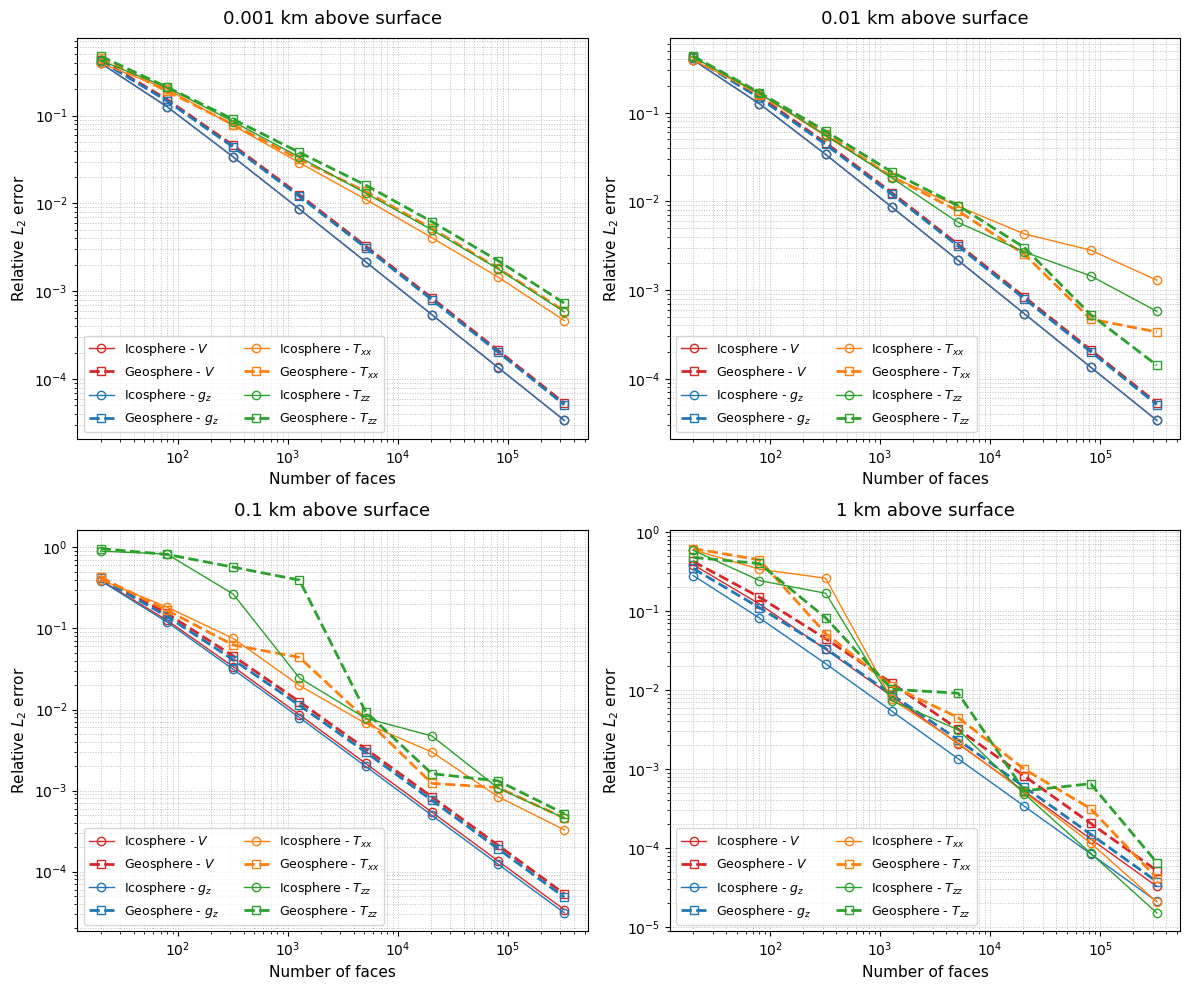

In [ ]:
# Plot representative fields for all z levels
rep_fields = ['V', 'gz', 'Txx', 'Tzz']
latex_labels = {'V': r'$V$', 'gz': r'$g_z$', 'Txx': r'$T_{xx}$', 'Tzz': r'$T_{zz}$'}
colors = {'V': 'tab:red', 'gz': 'tab:blue', 'Txx': 'tab:orange', 'Tzz': 'tab:green'}

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten() 

N_faces = 20 * (4 ** NSUBs)
for i, z0 in enumerate(z_levels):
    ax = axs[i]

    # Plot each field
    for field in rep_fields:
        label_latex = latex_labels[field]
        color = colors[field]

        # Icosphere
        ax.loglog(
            N_faces, all_err_ico[i][field],
            linestyle='-', marker='o', fillstyle='none',
            color=color, linewidth=1, markersize=6,
            label=f'Icosphere - {label_latex}'
        )
        # Geographic Grid
        ax.loglog(
            N_faces, all_err_geo[i][field],
            linestyle='--', marker='s', fillstyle='none',
            color=color, linewidth=2, markersize=6,
            label=f'Geosphere - {label_latex}'
        )

    ax.set_title(f'{z0:g} km above surface', fontsize=13, pad=10)
    ax.set_xlabel('Number of faces', fontsize=11)
    ax.set_ylabel('Relative $L_2$ error', fontsize=11)
    ax.grid(True, which="both", linestyle=':', linewidth=0.7, alpha=0.8)
    ax.legend(fontsize=9, loc='lower left', 
              frameon=True, fancybox=True, shadow=False, ncol=2)

plt.tight_layout()
plt.savefig("IcoGeoSphere_Zs.png", dpi=300, bbox_inches='tight')
plt.show()